# How well do the Benelux impact heads fit?

Six **quantile LightGBM** heads (plus a shallow CART explainer for habitat) map an infrastructure treatment to physical outcomes. This notebook scores the **saved artifacts** on the same validation split used at train time.

It does **not** evaluate the LLM narrator. Labels are a **synthetic recipe** (type priors, distance decay, water bump, noise), so a tight fit means the boosters recovered that recipe — not that they predict field measurements.

Heads: `habitatHa`, `riverTempC`, `vegStress`, `energyIdx`, `jobsFte`, `tco2e`. Each has p10 / p50 / p90.

In [4]:
from pathlib import Path
import json
import sys

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

HERE = Path.cwd().resolve()
for candidate in (HERE / "src", HERE / "models" / "src", HERE.parent / "models" / "src"):
    if (candidate / "impact_models").is_dir():
        sys.path.insert(0, str(candidate))
        break

from impact_models.features import FEATURE_COLUMNS, TYPE_INDEX
from impact_models.generate import HEADS, generate_frame
from impact_models import paths

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "figure.dpi": 110,
})
PALETTE = ["#1b4f72", "#148f77", "#b9770e", "#6c3483", "#922b21", "#1a5276"]
TYPE_NAMES = {v: k for k, v in TYPE_INDEX.items()}
COUNTRY_NAMES = {0: "NL", 1: "BE", 2: "LU"}
UNITS = {
    "habitatHa": "ha",
    "riverTempC": "°C",
    "vegStress": "index",
    "energyIdx": "index",
    "jobsFte": "FTE",
    "tco2e": "tCO2e/year",
}
print("artifacts", paths.ARTIFACTS_DIR)
print("features", len(FEATURE_COLUMNS))

artifacts C:\Users\skous\SpaceX-Hackathon\ai\models\artifacts
features 34


## Rebuild the validation split

Training used `n=4000`, `seed=7`, an 80/20 split. Regenerating that frame and split lets us score the committed boosters against held-out rows they were early-stopped on.

In [5]:
recorded = json.loads((paths.ARTIFACTS_DIR / "metrics.json").read_text(encoding="utf-8"))
n = int(recorded.get("n", 4000))
seed = 7

frame = generate_frame(n=n, seed=seed, include_observations=True)
x = frame[list(FEATURE_COLUMNS)].to_numpy(dtype=float)
_, _, idx_train, idx_val = train_test_split(x, np.arange(len(frame)), test_size=0.2, random_state=seed)
val = frame.iloc[idx_val].reset_index(drop=True)
x_val = val[list(FEATURE_COLUMNS)].to_numpy(dtype=float)

boosters = {}
for head in HEADS:
    for q in ("p10", "p50", "p90"):
        boosters[f"{head}_{q}"] = lgb.Booster(model_file=str(paths.BOOSTERS_DIR / f"{head}_{q}.txt"))
cart = joblib.load(paths.ARTIFACTS_DIR / "habitat_cart.joblib")

preds = {}
for head in HEADS:
    preds[head] = {q: boosters[f"{head}_{q}"].predict(x_val) for q in ("p10", "p50", "p90")}

print(f"val rows: {len(val)}  |  train rows: {len(idx_train)}  |  warehouse flags: {recorded.get('fetch')}")

val rows: 800  |  train rows: 3200  |  warehouse flags: {'gbif': False, 'roadkill': False, 'protected_areas': False, 'water': False, 'osm_roads': False, 'open_meteo': False, 'news': False}


C:\Users\skous\SpaceX-Hackathon\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## MAE by head and quantile

p50 should be the tightest. p10 / p90 are trained on pinball loss, so their MAE against the raw label is expected to be larger — they are not mean estimators.

quantile,p10,p50,p90
head,,,
habitatHa,9.088,2.674,7.712
riverTempC,0.209,0.090,0.191
vegStress,1.901,0.542,1.681
energyIdx,0.376,0.142,0.537
jobsFte,5.332,1.301,4.105
tco2e,227.752,39.623,148.500


p50 R²
head
habitatHa     0.961
riverTempC    0.929
vegStress     0.966
energyIdx     0.984
jobsFte       0.963
tco2e         0.987


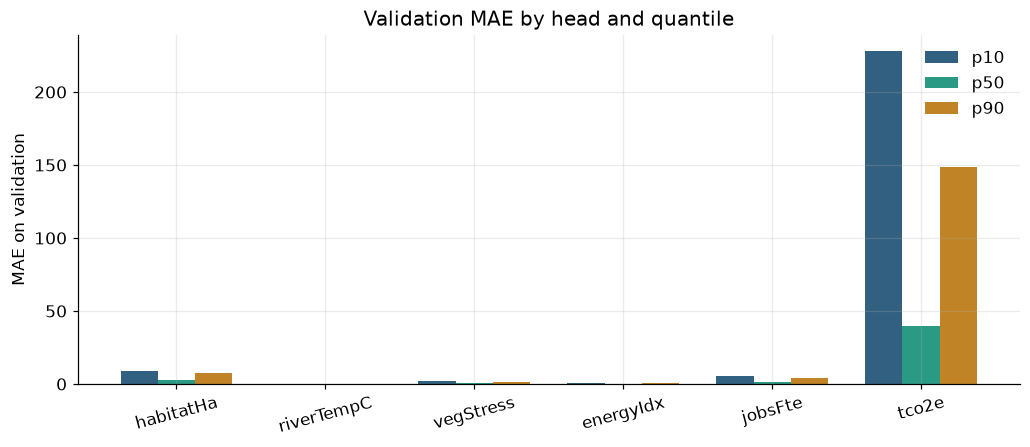

In [6]:
rows = []
for head in HEADS:
    y = val[head].to_numpy(dtype=float)
    for q in ("p10", "p50", "p90"):
        mae = float(mean_absolute_error(y, preds[head][q]))
        recorded_mae = recorded["heads"][head][q]["mae"]
        rows.append({
            "head": head,
            "quantile": q,
            "mae": mae,
            "recorded_mae": recorded_mae,
            "r2_p50": r2_score(y, preds[head]["p50"]) if q == "p50" else np.nan,
        })
metrics = pd.DataFrame(rows)
display(metrics.pivot(index="head", columns="quantile", values="mae").loc[list(HEADS), ["p10", "p50", "p90"]].round(3))
print("p50 R²")
print(metrics.loc[metrics["quantile"] == "p50", ["head", "r2_p50"]].set_index("head")["r2_p50"].round(3).to_string())

fig, ax = plt.subplots(figsize=(9.5, 4.2))
heads = list(HEADS)
x_pos = np.arange(len(heads))
width = 0.25
for i, q in enumerate(("p10", "p50", "p90")):
    vals = [metrics[(metrics["head"] == h) & (metrics["quantile"] == q)]["mae"].iloc[0] for h in heads]
    ax.bar(x_pos + (i - 1) * width, vals, width, label=q, color=PALETTE[i], alpha=0.9)
ax.set_xticks(x_pos)
ax.set_xticklabels(heads, rotation=15)
ax.set_ylabel("MAE on validation")
ax.set_title("Validation MAE by head and quantile")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Predicted vs actual (median)

Points should hug the diagonal. A systematic bow means the booster is smoothing over a non-linearity the recipe still has.

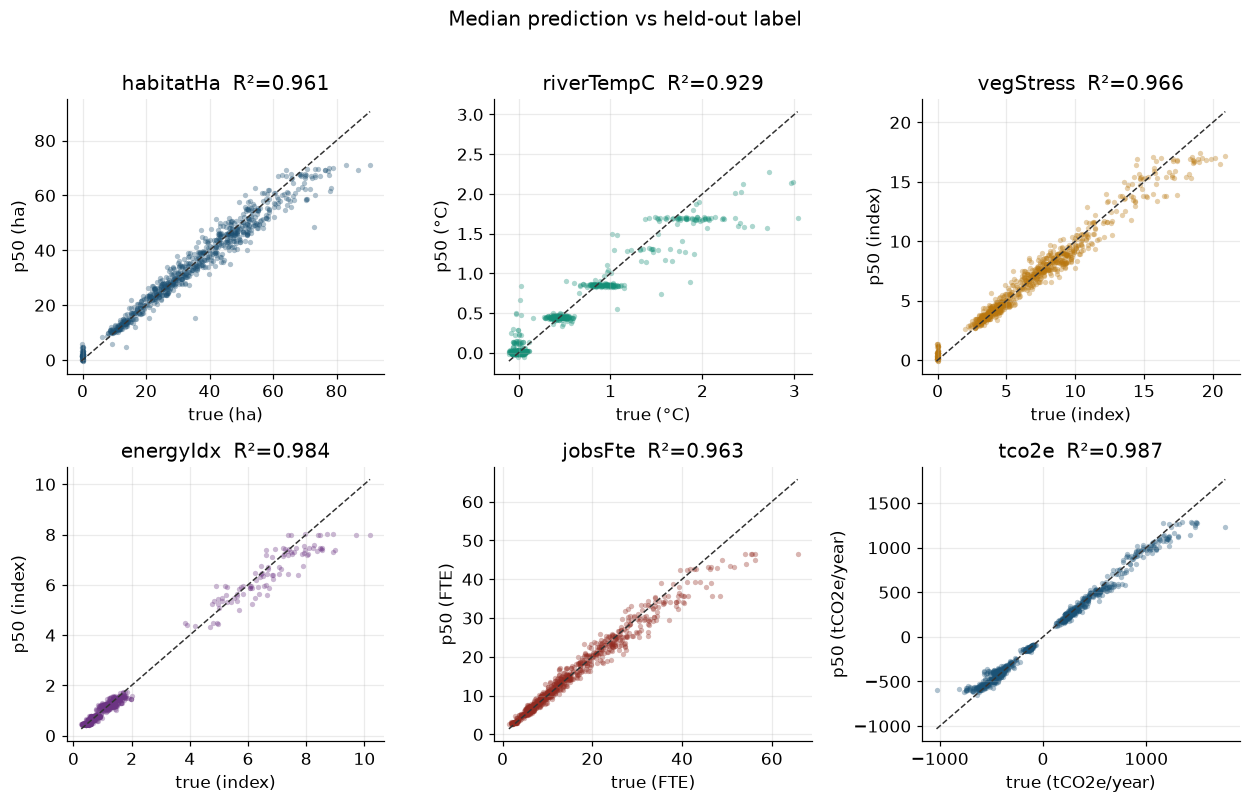

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.2))
for ax, head, color in zip(axes.ravel(), HEADS, PALETTE):
    y = val[head].to_numpy(dtype=float)
    yhat = preds[head]["p50"]
    ax.scatter(y, yhat, s=12, alpha=0.35, c=color, linewidths=0)
    lo = min(y.min(), yhat.min())
    hi = max(y.max(), yhat.max())
    ax.plot([lo, hi], [lo, hi], color="#333", lw=1, ls="--")
    ax.set_title(f"{head}  R²={r2_score(y, yhat):.3f}")
    ax.set_xlabel(f"true ({UNITS[head]})")
    ax.set_ylabel(f"p50 ({UNITS[head]})")
fig.suptitle("Median prediction vs held-out label", y=1.01)
fig.tight_layout()
plt.show()

## Quantile coverage

For well-calibrated quantiles, about **10%** of labels should fall below p10, **50%** below p50, **90%** below p90, and **80%** inside `[p10, p90]`. Coverage far from those targets means the interval is too tight or too wide.

,below_p10,below_p50,below_p90,inside_80,mean_width
head,,,,,
habitatHa,0.129,0.515,0.906,0.778,16.189
riverTempC,0.131,0.528,0.920,0.789,0.376
vegStress,0.111,0.529,0.922,0.811,3.464
energyIdx,0.090,0.495,0.931,0.841,0.866
jobsFte,0.091,0.568,0.916,0.825,9.104
tco2e,0.069,0.540,0.938,0.869,369.590


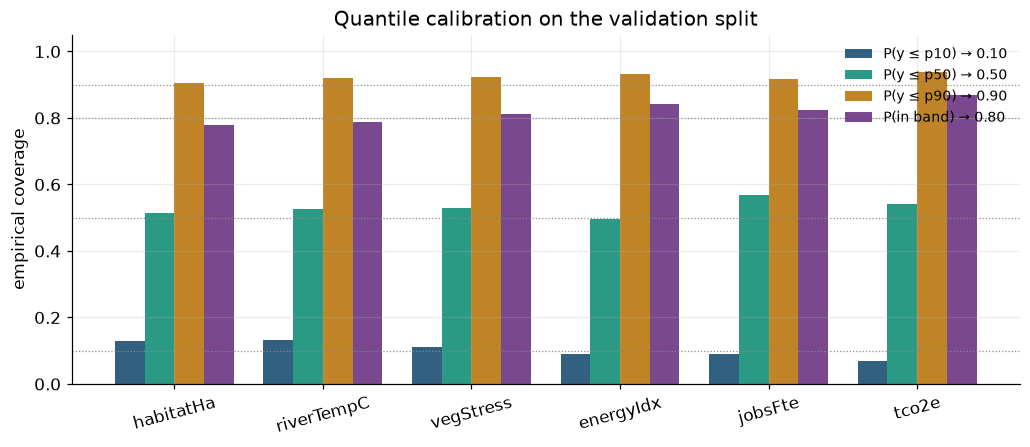

In [8]:
cover_rows = []
for head in HEADS:
    y = val[head].to_numpy(dtype=float)
    p10, p50, p90 = preds[head]["p10"], preds[head]["p50"], preds[head]["p90"]
    cover_rows.append({
        "head": head,
        "below_p10": float((y <= p10).mean()),
        "below_p50": float((y <= p50).mean()),
        "below_p90": float((y <= p90).mean()),
        "inside_80": float(((y >= p10) & (y <= p90)).mean()),
        "mean_width": float(np.mean(p90 - p10)),
    })
cover = pd.DataFrame(cover_rows).set_index("head").loc[list(HEADS)]
display(cover.round(3))

fig, ax = plt.subplots(figsize=(9.5, 4.2))
x_pos = np.arange(len(HEADS))
width = 0.2
targets = [0.10, 0.50, 0.90, 0.80]
series = ["below_p10", "below_p50", "below_p90", "inside_80"]
labels = ["P(y ≤ p10) → 0.10", "P(y ≤ p50) → 0.50", "P(y ≤ p90) → 0.90", "P(in band) → 0.80"]
for i, (col, lab) in enumerate(zip(series, labels)):
    ax.bar(x_pos + (i - 1.5) * width, cover[col].to_numpy(), width, label=lab, color=PALETTE[i], alpha=0.9)
for t in set(targets):
    ax.axhline(t, color="#888", lw=0.8, ls=":")
ax.set_xticks(x_pos)
ax.set_xticklabels(HEADS, rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("empirical coverage")
ax.set_title("Quantile calibration on the validation split")
ax.legend(frameon=False, fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

## Interval ribbon on a slice

Sort validation rows by true `habitatHa` and overlay p10–p90. Most labels should sit inside the band; the median should track the sorted truth.

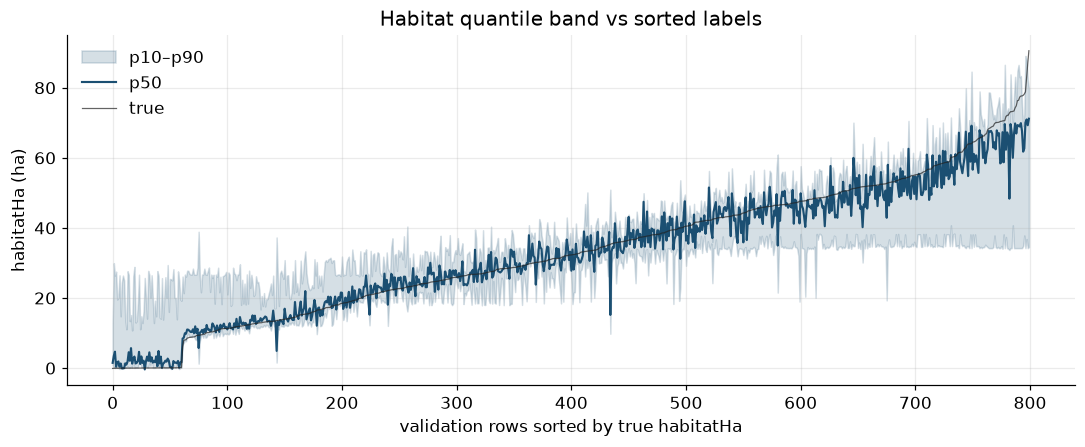

In [9]:
head = "habitatHa"
order = np.argsort(val[head].to_numpy())
y = val[head].to_numpy()[order]
p10 = preds[head]["p10"][order]
p50 = preds[head]["p50"][order]
p90 = preds[head]["p90"][order]
xs = np.arange(len(y))

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.fill_between(xs, p10, p90, color=PALETTE[0], alpha=0.18, label="p10–p90")
ax.plot(xs, p50, color=PALETTE[0], lw=1.4, label="p50")
ax.plot(xs, y, color="#222", lw=0.8, alpha=0.7, label="true")
ax.set_xlabel("validation rows sorted by true habitatHa")
ax.set_ylabel("habitatHa (ha)")
ax.set_title("Habitat quantile band vs sorted labels")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Residual shape (p50)

Centered, roughly symmetric residuals are what we want after the recipe noise (~8% of |y|). Heavy tails on `tco2e` are expected: that head has the widest numeric range.

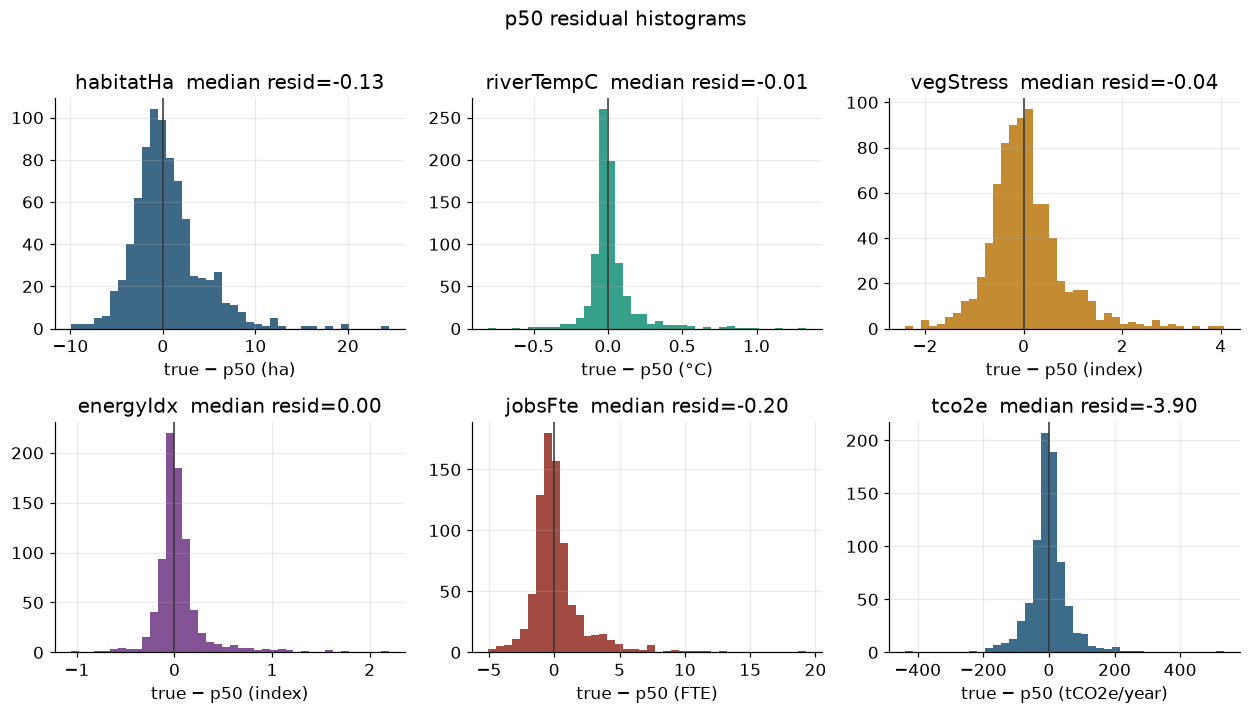

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.4))
for ax, head, color in zip(axes.ravel(), HEADS, PALETTE):
    resid = val[head].to_numpy(dtype=float) - preds[head]["p50"]
    ax.hist(resid, bins=40, color=color, alpha=0.85)
    ax.axvline(0, color="#333", lw=1)
    ax.set_title(f"{head}  median resid={np.median(resid):.2f}")
    ax.set_xlabel(f"true − p50 ({UNITS[head]})")
fig.suptitle("p50 residual histograms", y=1.01)
fig.tight_layout()
plt.show()

## Feature importance

Gain importance from the median boosters. Type, scale, mitigations, and distance-to-habitat/water should dominate; GBIF/roadkill kernels are near-zero while the warehouse is empty.

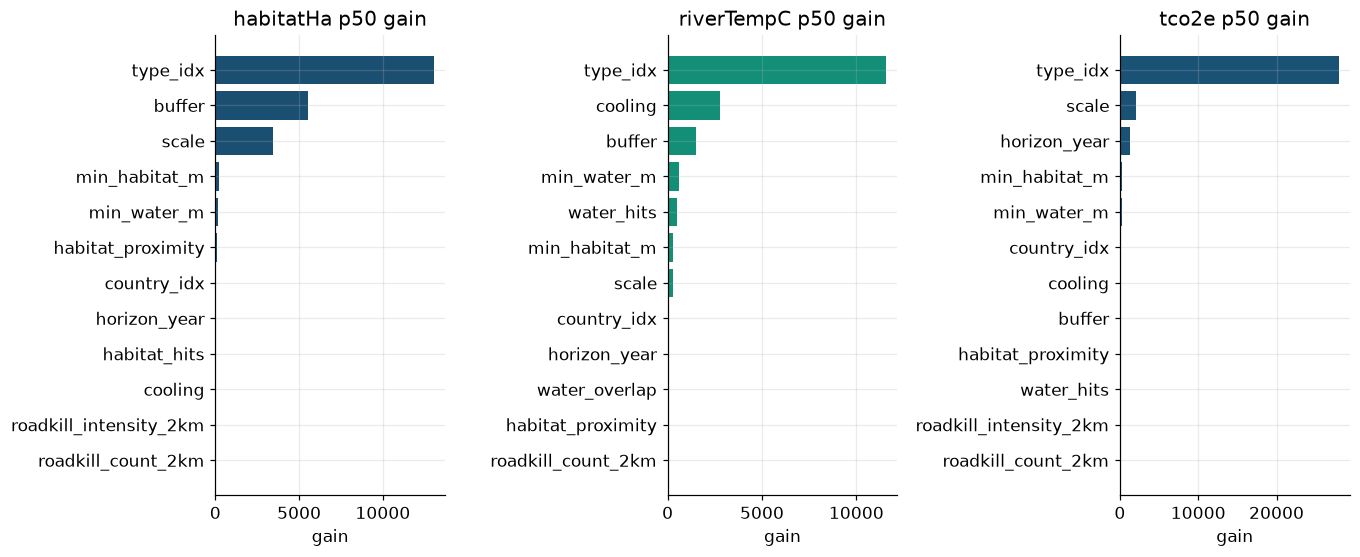

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 5.2))
for ax, head in zip(axes, ("habitatHa", "riverTempC", "tco2e")):
    booster = boosters[f"{head}_p50"]
    gain = booster.feature_importance(importance_type="gain")
    order = np.argsort(gain)[-12:]
    ax.barh(np.array(FEATURE_COLUMNS)[order], gain[order], color=PALETTE[HEADS.index(head)])
    ax.set_title(f"{head} p50 gain")
    ax.set_xlabel("gain")
fig.tight_layout()
plt.show()

## CART explainer vs LightGBM (habitat)

The depth-4 tree is the text shown on the report. It should follow the same trend as the habitat p50 booster, with more stepwise error — that is the point of a readable explainer.

LightGBM p50 MAE=2.674  R²=0.961
CART          MAE=7.510  R²=0.725
recorded cartMae=7.510


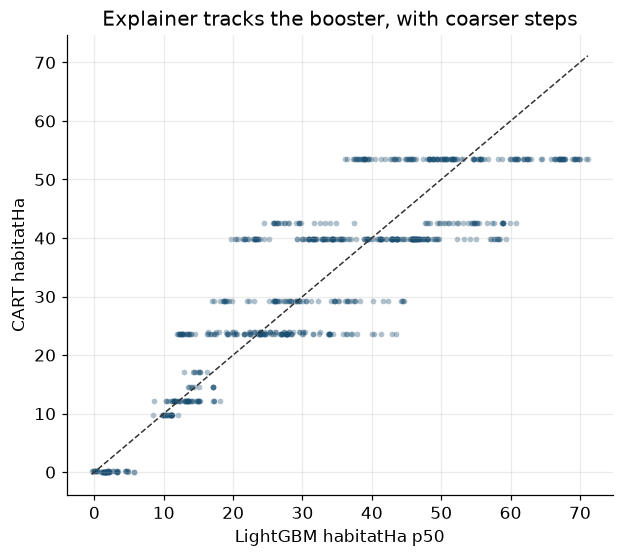

In [12]:
y = val["habitatHa"].to_numpy(dtype=float)
lgb_hat = preds["habitatHa"]["p50"]
cart_hat = cart.predict(x_val)
print(f"LightGBM p50 MAE={mean_absolute_error(y, lgb_hat):.3f}  R²={r2_score(y, lgb_hat):.3f}")
print(f"CART          MAE={mean_absolute_error(y, cart_hat):.3f}  R²={r2_score(y, cart_hat):.3f}")
print(f"recorded cartMae={recorded.get('cartMae'):.3f}")

fig, ax = plt.subplots(figsize=(5.8, 5.2))
ax.scatter(lgb_hat, cart_hat, s=14, alpha=0.35, c=PALETTE[0], linewidths=0)
lo = min(lgb_hat.min(), cart_hat.min())
hi = max(lgb_hat.max(), cart_hat.max())
ax.plot([lo, hi], [lo, hi], color="#333", ls="--", lw=1)
ax.set_xlabel("LightGBM habitatHa p50")
ax.set_ylabel("CART habitatHa")
ax.set_title("Explainer tracks the booster, with coarser steps")
fig.tight_layout()
plt.show()

## Error by project type and country

If one type or country is much worse, the recipe or the sample weights are uneven there. Highway habitat is the most nonlinear head (roadkill × nearby road).

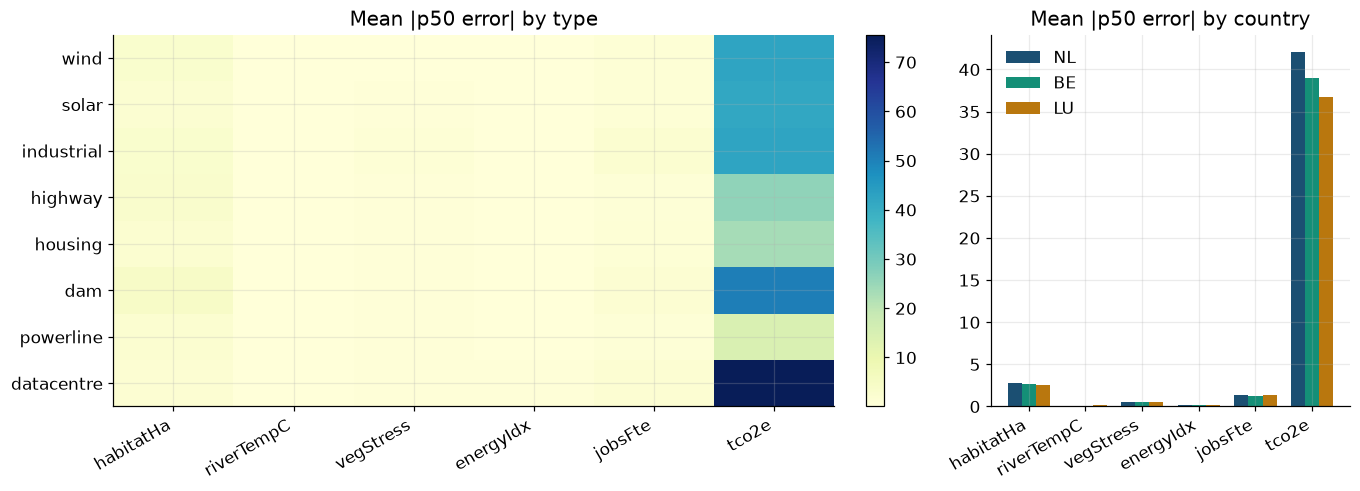

,habitatHa,riverTempC,vegStress,energyIdx,jobsFte,tco2e
type,,,,,,
wind,2.81,0.04,0.31,0.06,1.12,42.46
solar,2.01,0.04,0.46,0.07,0.97,41.49
industrial,2.75,0.13,1.17,0.12,2.36,42.43
highway,3.16,0.07,0.49,0.13,0.69,26.12
housing,2.39,0.07,0.47,0.12,1.17,23.21
dam,4.34,0.19,0.51,0.06,1.76,50.55
powerline,2.22,0.06,0.43,0.08,0.73,14.47
datacentre,1.67,0.11,0.47,0.50,1.60,75.57


,habitatHa,riverTempC,vegStress,energyIdx,jobsFte,tco2e
country,,,,,,
NL,2.80,0.09,0.53,0.14,1.36,42.01
BE,2.61,0.08,0.55,0.14,1.21,38.95
LU,2.58,0.13,0.53,0.15,1.41,36.75


In [13]:
abs_err = pd.DataFrame({
    head: np.abs(val[head].to_numpy(dtype=float) - preds[head]["p50"])
    for head in HEADS
})
abs_err["type"] = val["type_idx"].map(TYPE_NAMES)
abs_err["country"] = val["country_idx"].map(COUNTRY_NAMES)

by_type = abs_err.groupby("type")[list(HEADS)].mean().reindex([TYPE_NAMES[i] for i in range(len(TYPE_NAMES))])
by_country = abs_err.groupby("country")[list(HEADS)].mean().reindex(["NL", "BE", "LU"])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={"width_ratios": [2.2, 1]})
im = axes[0].imshow(by_type.to_numpy(), aspect="auto", cmap="YlGnBu")
axes[0].set_xticks(range(len(HEADS)), HEADS, rotation=30, ha="right")
axes[0].set_yticks(range(len(by_type.index)), by_type.index)
axes[0].set_title("Mean |p50 error| by type")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

x_pos = np.arange(len(HEADS))
width = 0.25
for i, country in enumerate(["NL", "BE", "LU"]):
    axes[1].bar(x_pos + (i - 1) * width, by_country.loc[country].to_numpy(), width, label=country, color=PALETTE[i])
axes[1].set_xticks(x_pos, HEADS, rotation=30, ha="right")
axes[1].set_title("Mean |p50 error| by country")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

display(by_type.round(2))
display(by_country.round(2))

## Takeaways

- Median heads recover the synthetic recipe closely (high p50 R², small residuals).
- Quantile bands should sit near 10 / 50 / 90 / 80 coverage; check the calibration chart if you retrain.
- CART is coarser than LightGBM on habitat by design — it is the readable split shown on the report.
- With an empty warehouse, GBIF/roadkill/weather columns are zeros, so importance concentrates on type, scale, buffer/cooling, and distance-to-habitat/water.
- Retrain after Benelux `data/raw` files land; coverage and GBIF importances should move.